In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.1/112.6 GB disk)


## Fine-tune YOLO11 on custom dataset

In [ ]:
!pip install ultralytics
!pip install roboflow

!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

rf = Roboflow(api_key="Y1GMNsMSqM91BzRdxF18")
project = rf.workspace("traffic-6kfw3").project("traffic-bangladesh-hail-hydra")
version = project.version(6)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Bangladesh-Hail-Hydra-6 in yolov11:: 100%|██████████| 29140/29140 [00:06<00:00, 4466.57it/s]


/content


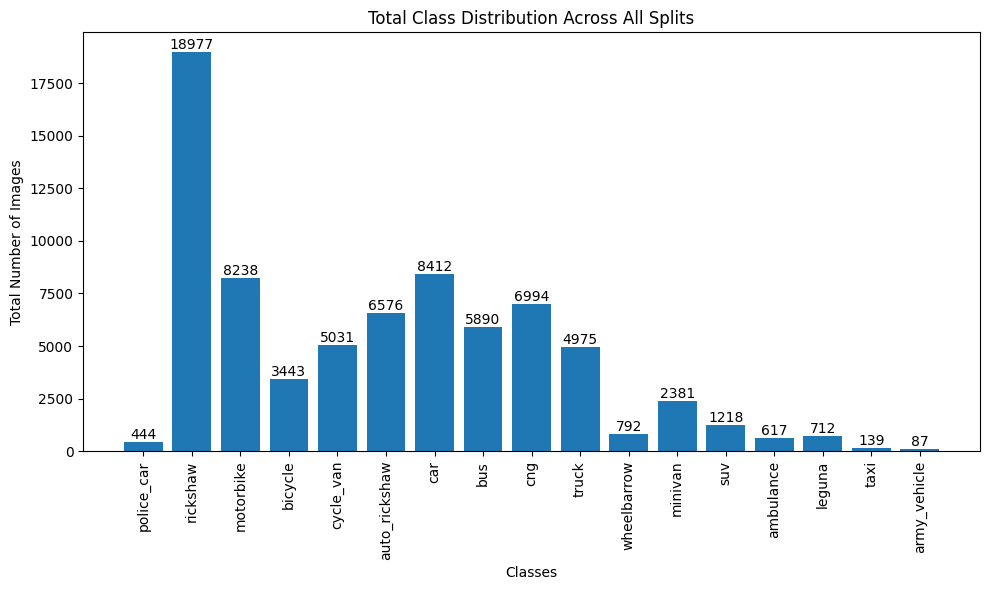

In [ ]:
import os
import matplotlib.pyplot as plt
import yaml

%cd {HOME}

# Define paths for the dataset
dataset_splits = ["train", "valid", "test"]
class_counts_per_split = {}

# Count occurrences of each class in all splits
for split in dataset_splits:
    label_folder = os.path.join(dataset.location, split, "labels")
    class_counts = {}
    for filename in os.listdir(label_folder):
        with open(os.path.join(label_folder, filename), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id not in class_counts:
                    class_counts[class_id] = 0
                class_counts[class_id] += 1
    class_counts_per_split[split] = class_counts

# Load class names from data.yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# Aggregate class counts across all splits
total_class_counts = {class_id: 0 for class_id in class_counts_per_split["train"].keys()}
for split in dataset_splits:
    for class_id, count in class_counts_per_split[split].items():
        total_class_counts[class_id] += count

# Create a bar chart to show the total distribution of classes across all splits
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(total_class_counts)), list(total_class_counts.values()))
plt.xticks(range(len(total_class_counts)), [class_names[i] for i in total_class_counts.keys()], rotation=90)
plt.xlabel("Classes")
plt.ylabel("Total Number of Images")
plt.title("Total Class Distribution Across All Splits")

# Add text annotations on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()


/content
Class               Train          Valid          Test           
-----------------------------------------------------------------
police_car          347            66             31             
rickshaw            13265          3873           1839           
motorbike           5404           1671           1163           
bicycle             2574           641            228            
cycle_van           3858           1127           46             
auto_rickshaw       5007           1374           195            
car                 3734           1832           2846           
bus                 2926           1168           1796           
cng                 3946           1464           1584           
truck               2592           992            1391           
wheelbarrow         548            177            67             
minivan             1038           493            850            
suv                 521            269            428            
a

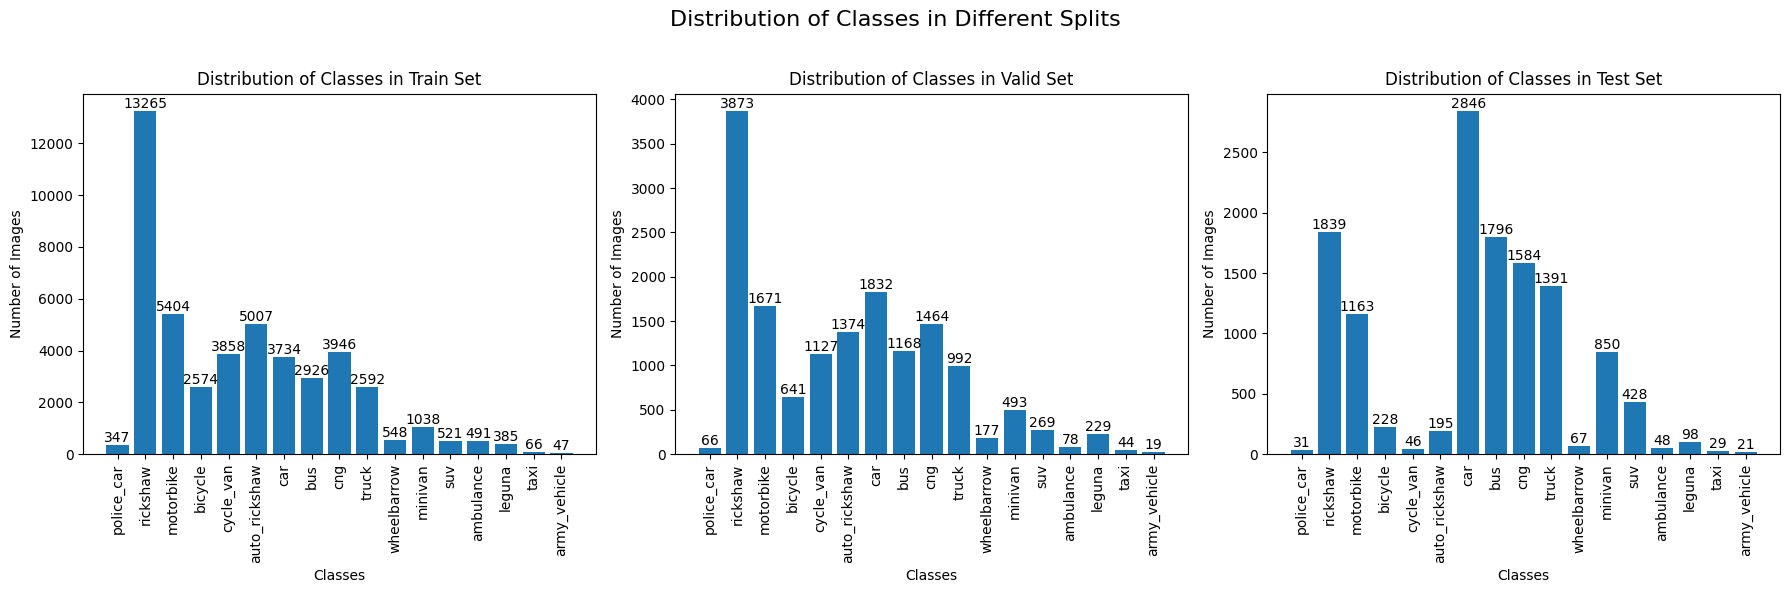

In [ ]:
import os
import matplotlib.pyplot as plt
import yaml
from collections import OrderedDict
import matplotlib.image as mpimg
import numpy as np

%cd {HOME}

def count_classes(folder):
    """Counts the occurrences of each class in a dataset folder."""
    label_folder = os.path.join(folder, "labels")
    class_counts = {}
    for filename in os.listdir(label_folder):
        with open(os.path.join(label_folder, filename), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id not in class_counts:
                    class_counts[class_id] = 0
                class_counts[class_id] += 1
    return class_counts

# Assuming 'dataset.location' is defined and holds the base directory of the dataset
dataset_splits = ["train", "valid", "test"]
class_counts_per_split = {}

for split in dataset_splits:
    folder = os.path.join(dataset.location, split)
    class_counts_per_split[split] = count_classes(folder)

# Load class names from data.yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# Print class counts side by side
# Create an ordered set of all classes in all splits to have a common order and make sure all classes are displayed
all_classes = OrderedDict()
for split in dataset_splits:
    for class_id in class_counts_per_split[split].keys():
        if class_id not in all_classes:
             all_classes[class_id] = None

# Print header with split names
header = "Class".ljust(20)
for split in dataset_splits:
    header += f"{split.capitalize()}".ljust(15)
print(header)
print("-" * len(header))

for class_id in all_classes.keys():
    line = class_names[class_id].ljust(20)
    for split in dataset_splits:
        count = class_counts_per_split[split].get(class_id, 0)
        line += f"{count}".ljust(15)
    print(line)
print()

# Create bar charts for each split side by side
fig_bars, axes_bars = plt.subplots(1, len(dataset_splits), figsize=(6 * len(dataset_splits), 6))
fig_bars.suptitle("Distribution of Classes in Different Splits\n", fontsize=16)

for i, split in enumerate(dataset_splits):
    class_counts = class_counts_per_split[split]
    ax = axes_bars[i] if len(dataset_splits) > 1 else axes_bars

    # Use all_classes keys to order the bars
    ordered_class_ids = list(all_classes.keys())
    ordered_counts = [class_counts.get(class_id, 0) for class_id in ordered_class_ids]

    bars = ax.bar(range(len(ordered_class_ids)), ordered_counts)
    ax.set_xticks(range(len(ordered_class_ids)))
    ax.set_xticklabels([class_names[i] for i in ordered_class_ids], rotation=90)
    ax.set_xlabel("Classes")
    ax.set_ylabel("Number of Images")
    ax.set_title(f"Distribution of Classes in {split.capitalize()} Set")

    # Add text annotations on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

/content
100% 5.35M/5.35M [00:00<00:00, 111MB/s]
New https://pypi.org/project/ultralytics/8.3.78 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/datasets/Traffic-Bangladesh-Hail-Hydra-6/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    R_curve.png		 val_batch0_labels.jpg
confusion_matrix_normalized.png			    results.csv		 val_batch0_pred.jpg
confusion_matrix.png				    results.png		 val_batch1_labels.jpg
events.out.tfevents.1740482643.d8e3a8120288.1895.0  train_batch0.jpg	 val_batch1_pred.jpg
F1_curve.png					    train_batch1.jpg	 val_batch2_labels.jpg
labels_correlogram.jpg				    train_batch2.jpg	 val_batch2_pred.jpg
labels.jpg					    train_batch6380.jpg  weights
P_curve.png					    train_batch6381.jpg
PR_curve.png					    train_batch6382.jpg


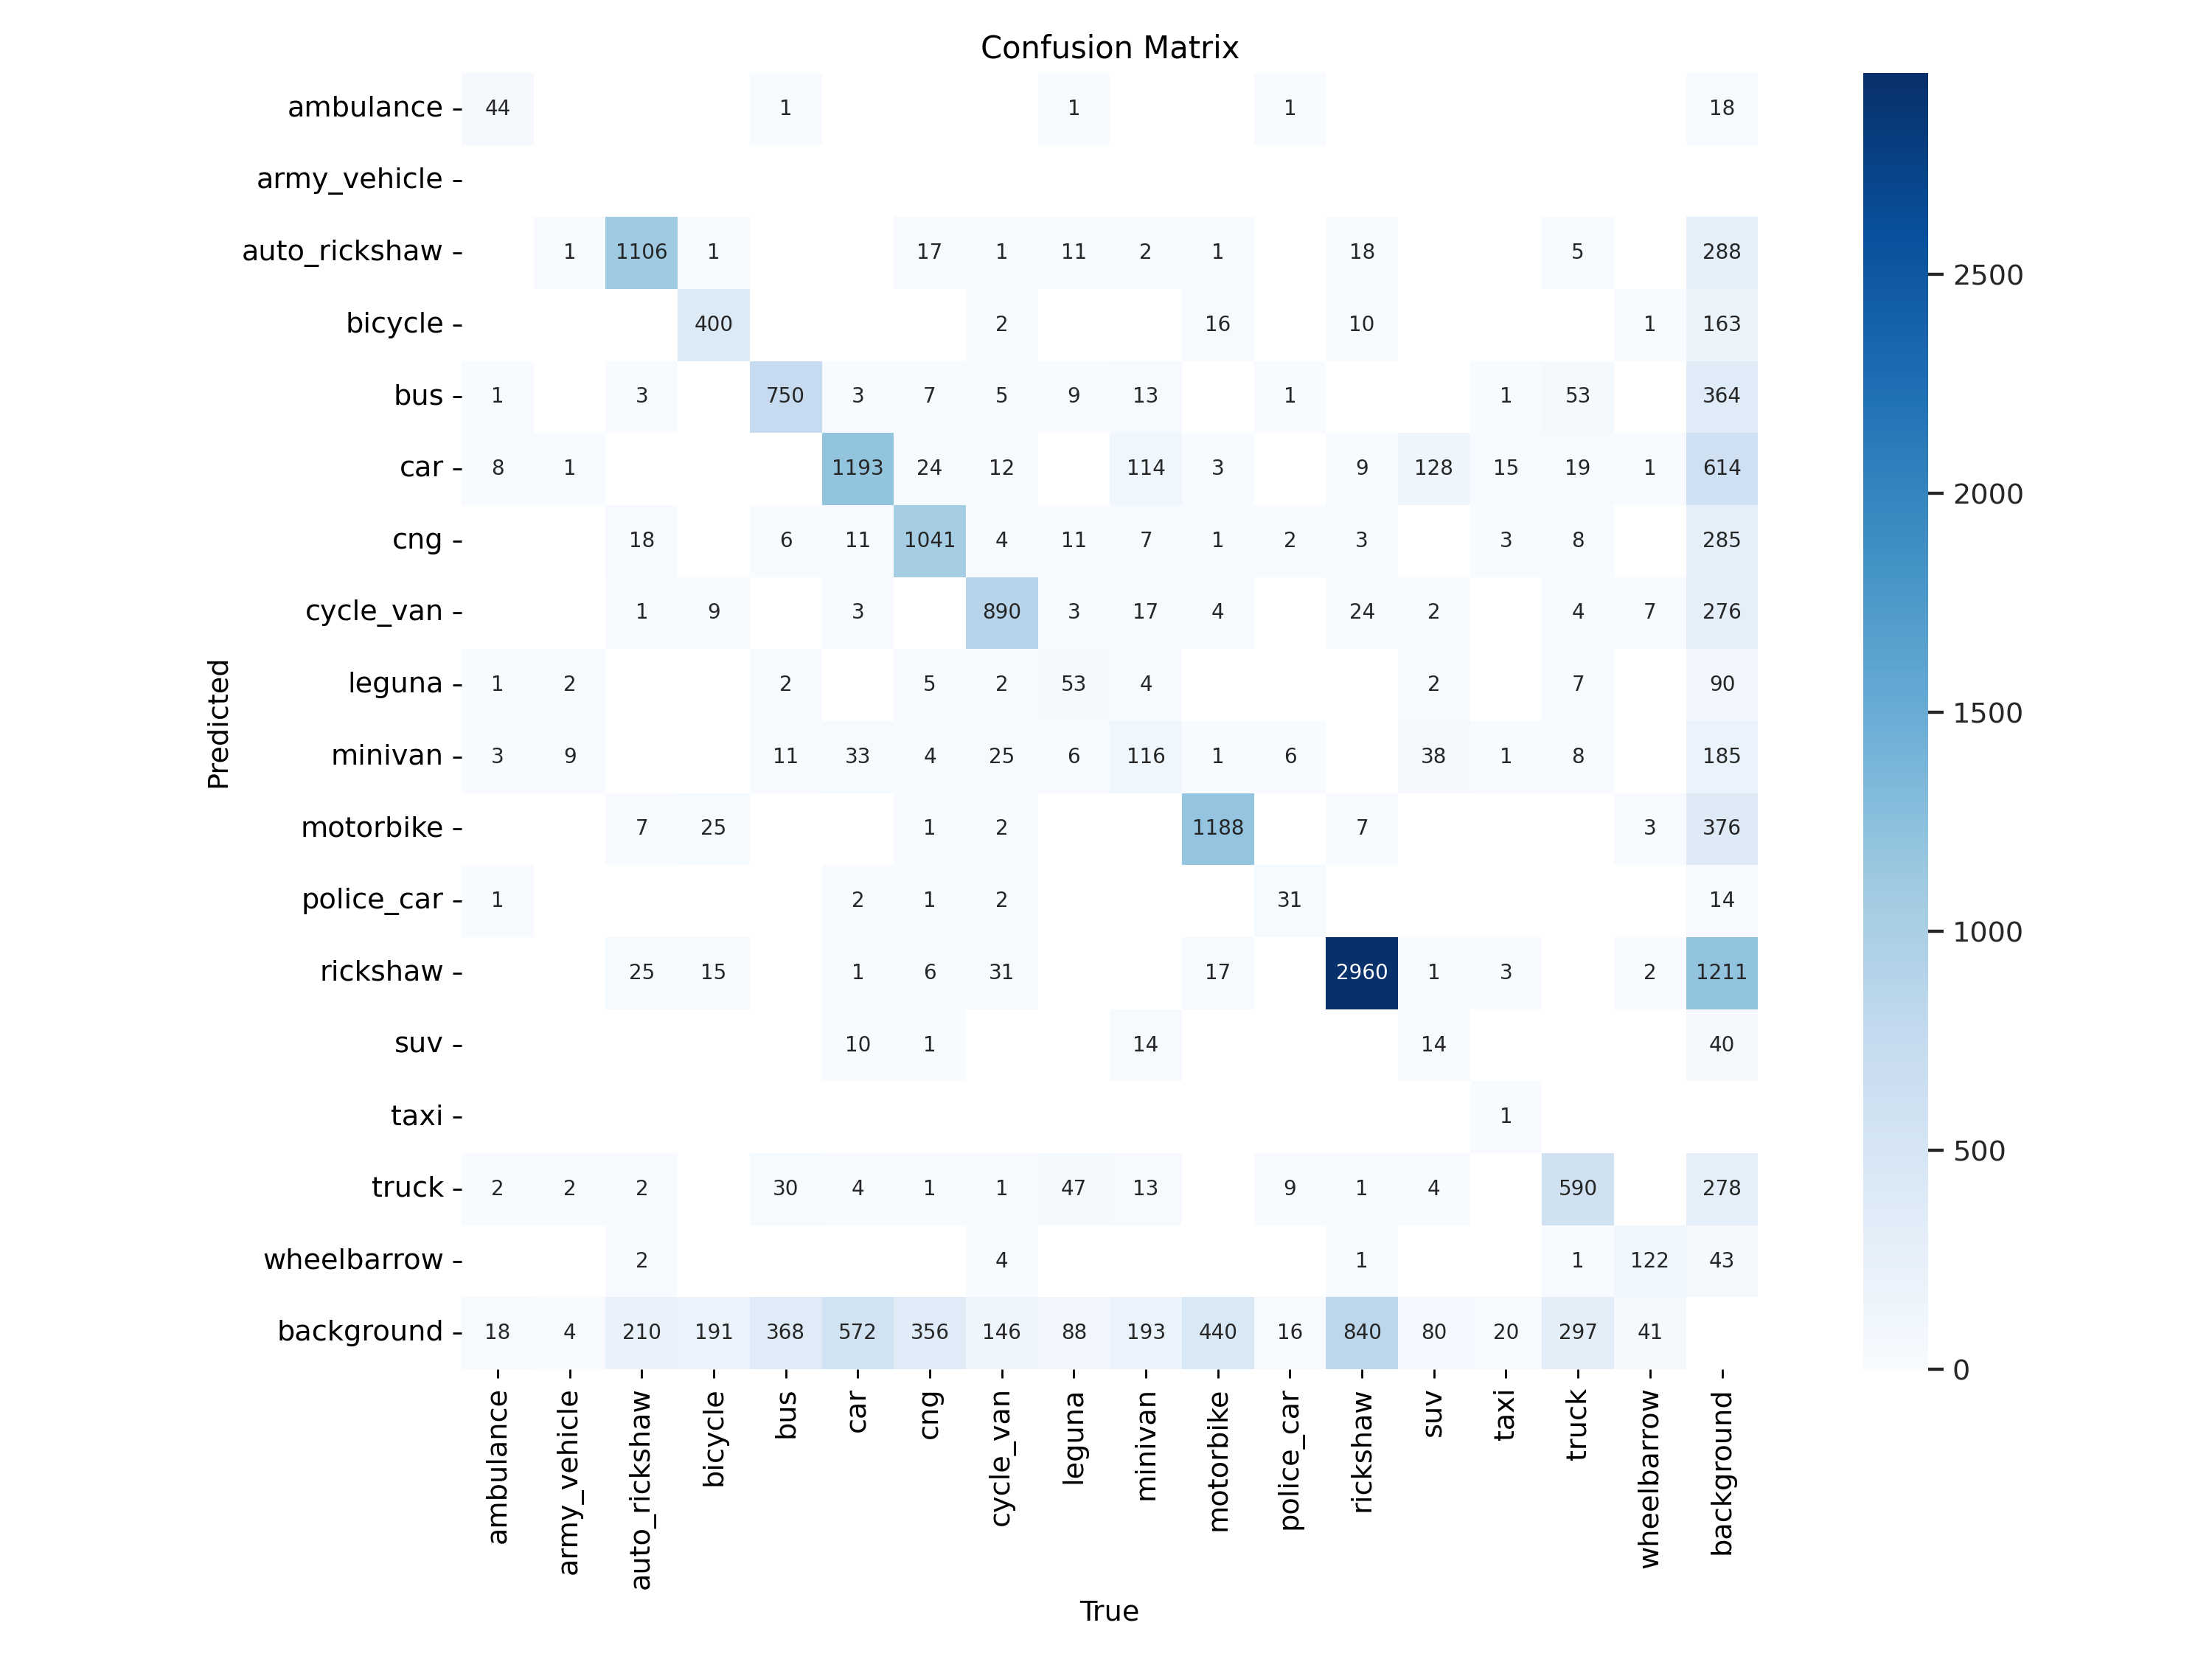

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

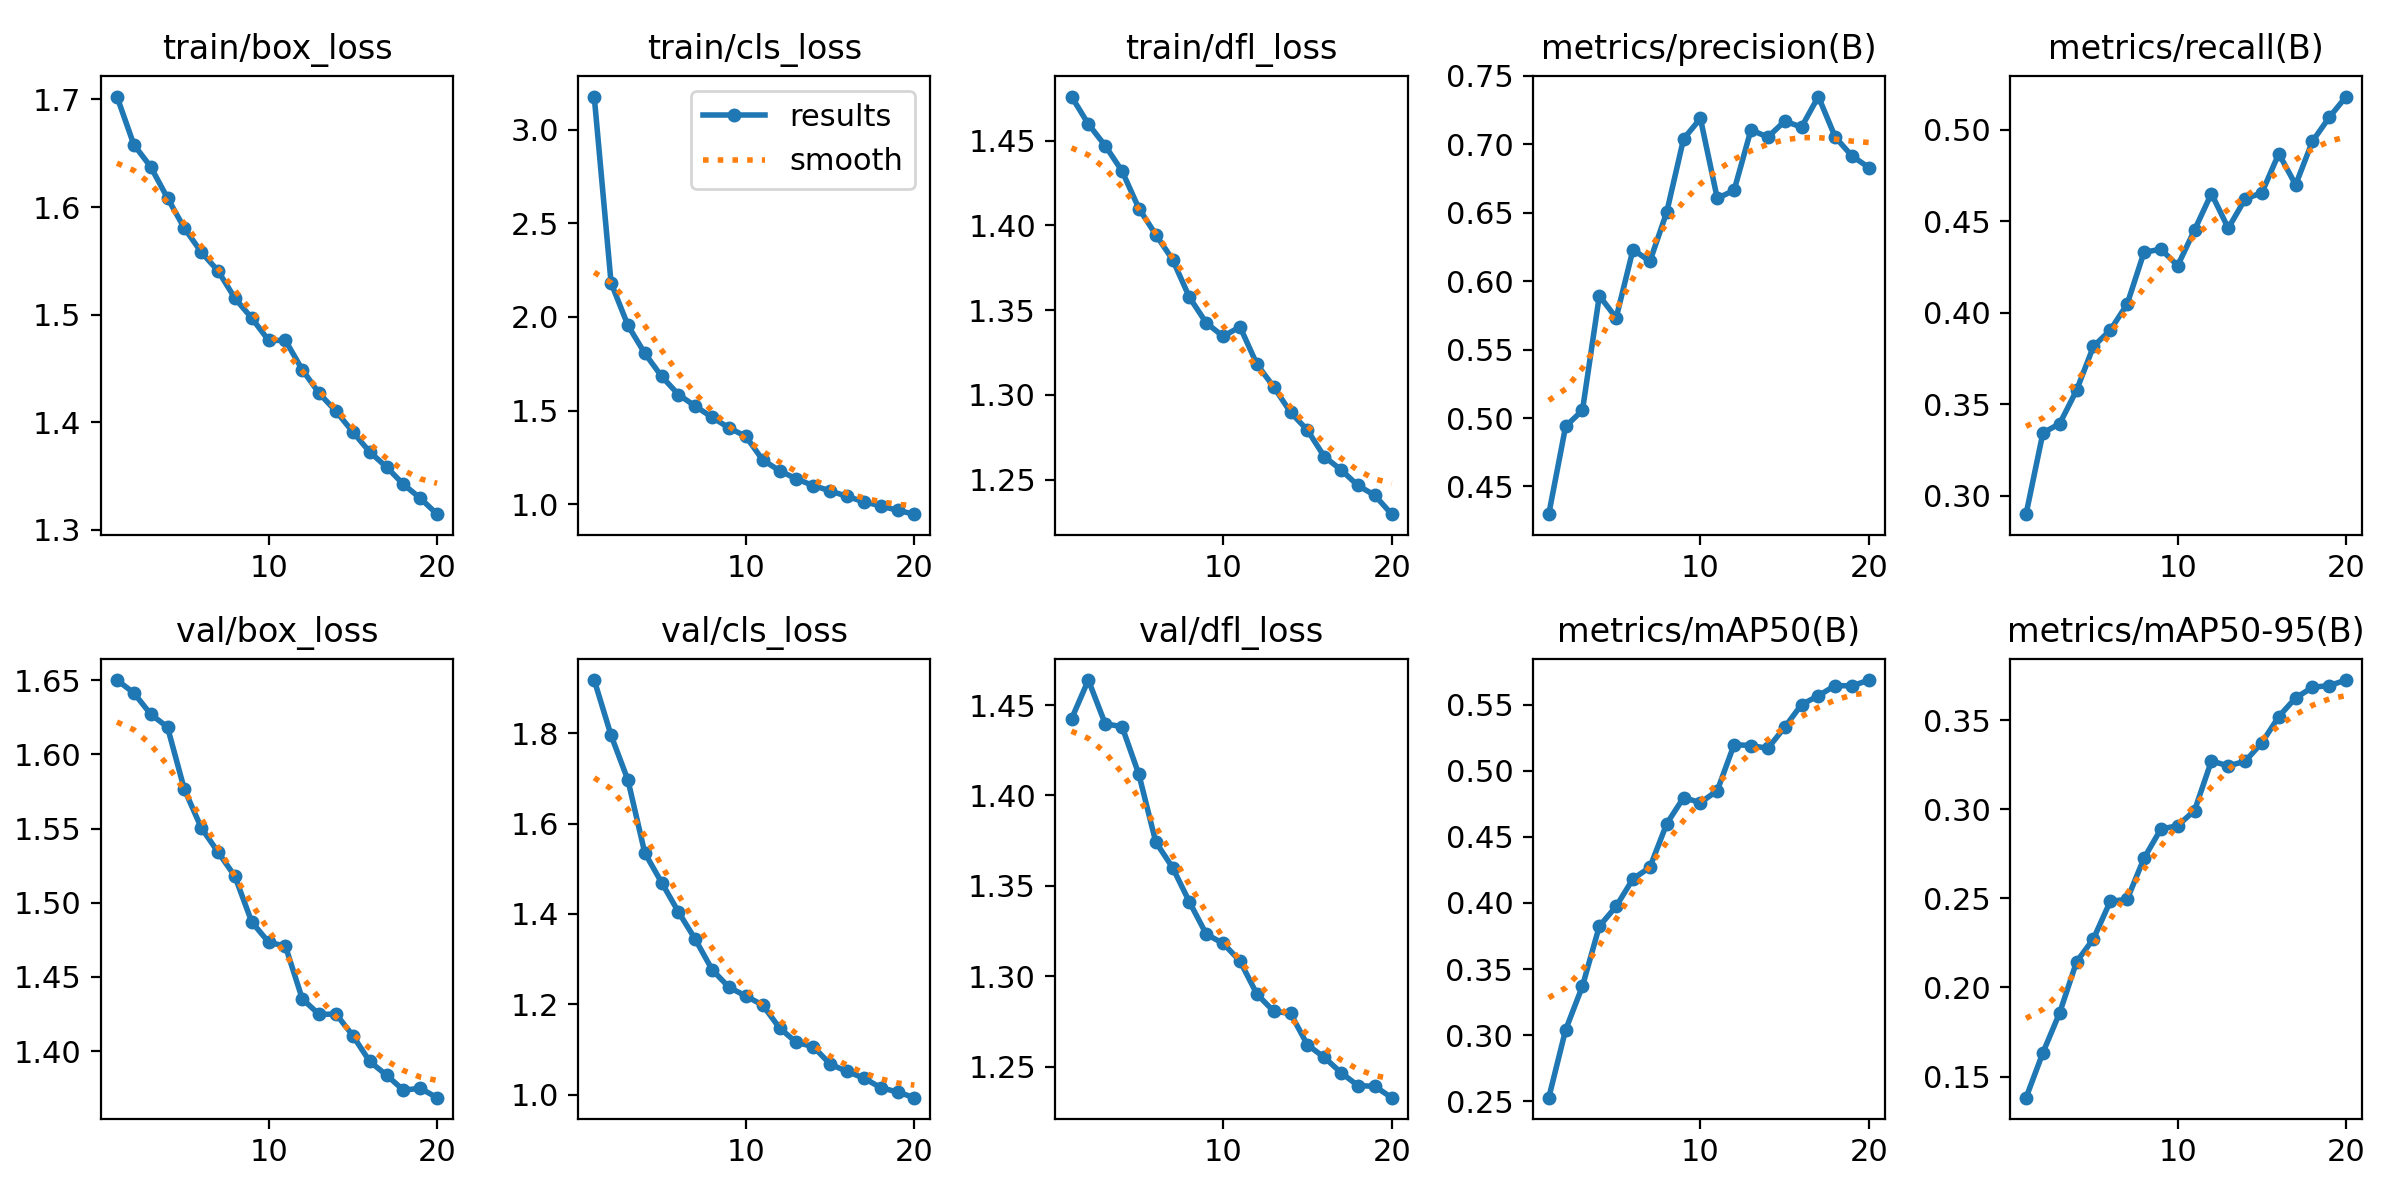

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

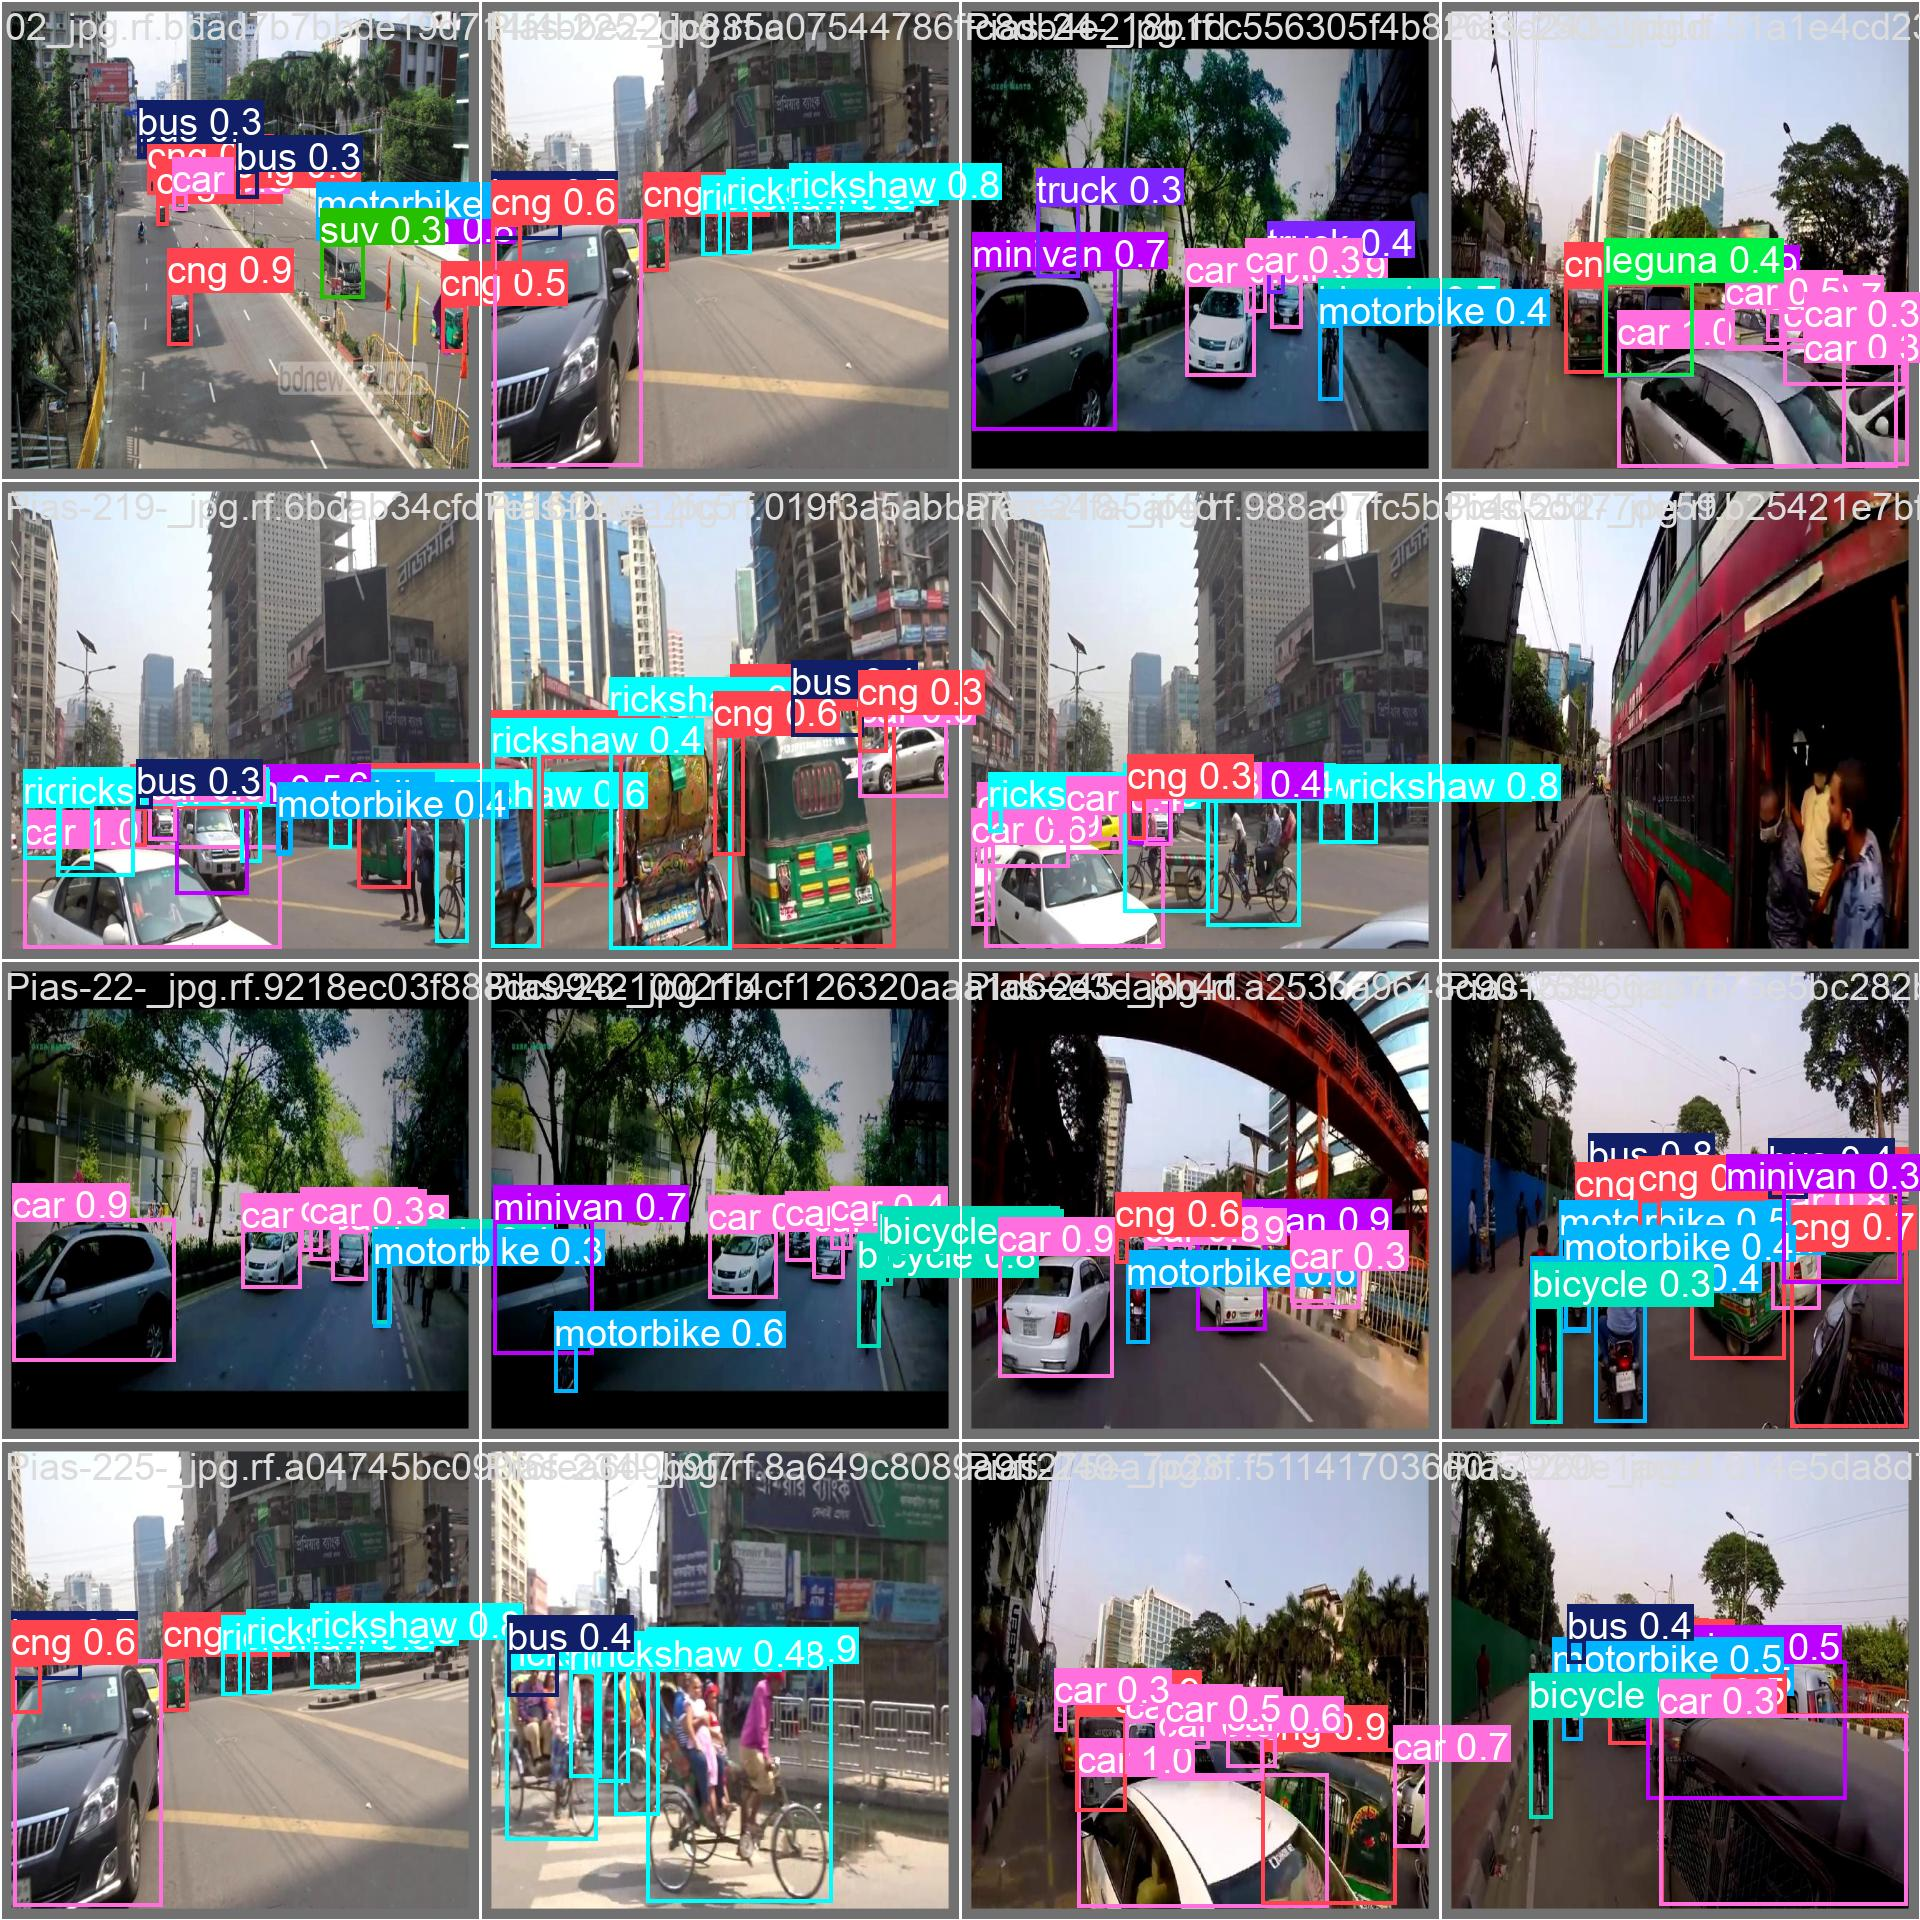

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=1000)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,585,467 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/datasets/Traffic-Bangladesh-Hail-Hydra-6/valid/labels.cache... 2912 images, 0 backgrounds, 0 corrupt: 100% 2912/2912 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 65, len(boxes) = 15517. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 182/182 [00:31<00:00,  5.77it/s]
                   all       2912      15517      0.683      0.518      0.569      0.373
             ambulance         71         78      0.668      0.542      0.596      0.498
          army_vehicle         16         19          1          0        0.2      0.177
         a

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,585,467 parameters, 0 gradients, 6.3 GFLOPs

image 1/1456 /content/datasets/Traffic-Bangladesh-Hail-Hydra-6/test/images/01_jpg.rf.9030ed34a8d6bc8dcefb63d828e2fa34.jpg: 640x640 4 buss, 3 cars, 4 cngs, 1 motorbike, 9 rickshaws, 11.4ms
image 2/1456 /content/datasets/Traffic-Bangladesh-Hail-Hydra-6/test/images/01_jpg.rf.e422691a0feb40da184a5a116081ee1f.jpg: 640x640 4 buss, 3 cars, 4 cngs, 1 motorbike, 9 rickshaws, 9.3ms
image 3/1456 /content/datasets/Traffic-Bangladesh-Hail-Hydra-6/test/images/02_jpg.rf.a729bec849e7525d6397ab04211c9849.jpg: 640x640 3 buss, 1 car, 5 cngs, 1 minivan, 1 motorbike, 2 rickshaws, 8.7ms
image 4/1456 /content/datasets/Traffic-Bangladesh-Hail-Hydra-6/test/images/02_jpg.rf.b8ad32b953979cf2acfceb575d643799.jpg: 640x640 3 buss, 1 car, 5 cngs, 1 minivan, 1 motorbike, 2 rickshaws, 8.3ms
image 5/1456 /content/datasets/Traffic-Bangladesh-Hail-Hydra-6/te

**NOTE:** Let's take a look at few results.

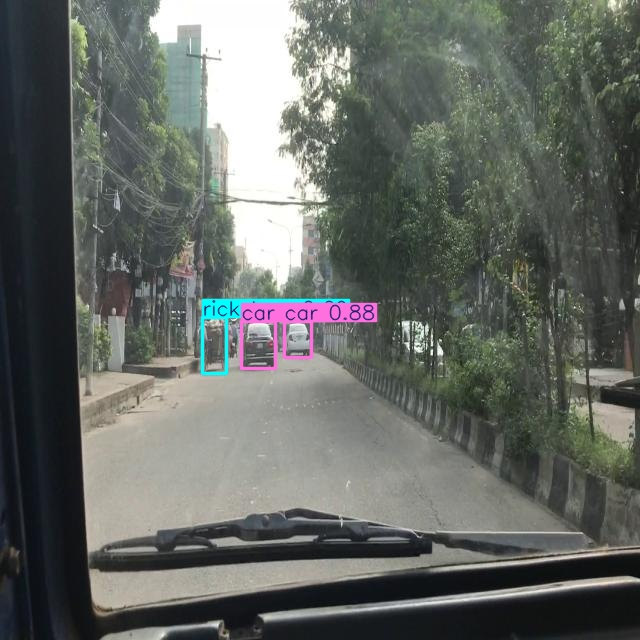

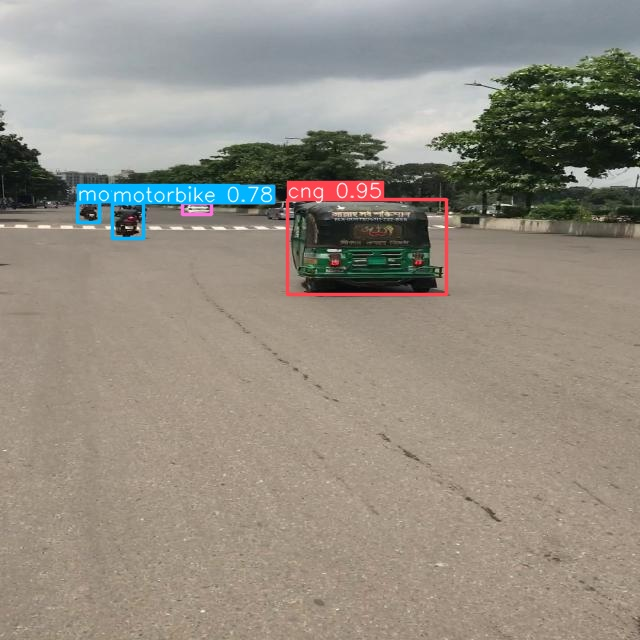

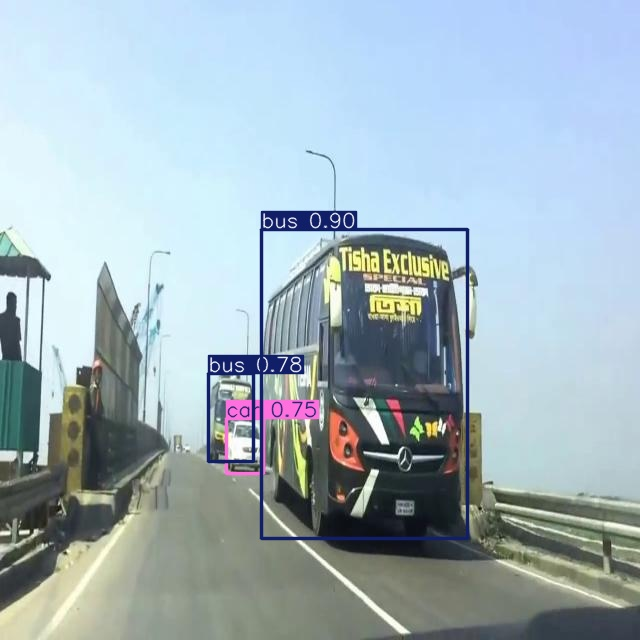

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,585,467 parameters, 0 gradients, 6.3 GFLOPs

100% 114k/114k [00:00<00:00, 10.8MB/s]
image 1/1 /content/atudents-traffic-moghbazar-7-aug.jpg: 384x640 2 buss, 3 cars, 3 cngs, 8 rickshaws, 43.7ms
Speed: 2.0ms preprocess, 43.7ms inference, 131.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,585,467 parameters, 0 gradients, 6.3 GFLOPs

Found https://www.tbsnews.net/sites/default/files/styles/big_3/public/images/2024/08/07/atudents-traffic-moghbazar-7-aug.jpg locally at atudents-traffic-moghbazar-7-aug.jpg
image 1/1 /content/atudents-traffic-moghbazar-7-aug.jpg: 384x640 2 buss, 3 cars, 3 cngs, 8 rickshaws, 44.3ms
Speed: 1.9ms preprocess, 44.3ms inference,

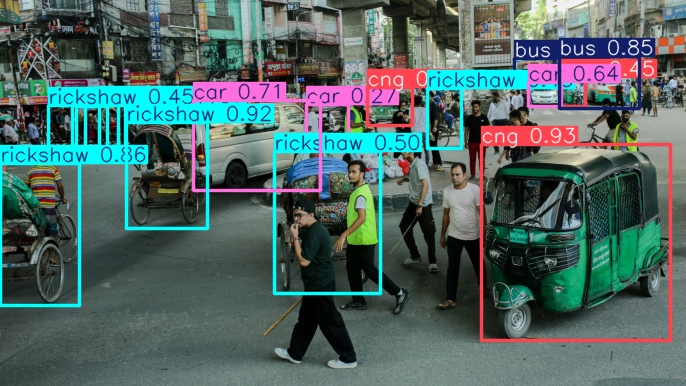

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='https://www.tbsnews.net/sites/default/files/styles/big_3/public/images/2024/08/07/atudents-traffic-moghbazar-7-aug.jpg' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='https://www.tbsnews.net/sites/default/files/styles/big_3/public/images/2024/08/07/atudents-traffic-moghbazar-7-aug.jpg' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

In [ ]:
import time
from google.colab import files

# Step 1: Define path to the model weights
# Corrected path: Assuming training output is in 'runs/detect/train'
model_weights_path = 'runs/detect/train/weights/best.pt'
# If your training output is in 'runs/detect/train2', then keep the original path

# Step 2: Start the timer
start_time = time.time()

# Download the model weights
files.download(model_weights_path)

# Step 3: Calculate the time taken to download
end_time = time.time()
download_time = end_time - start_time

# Print the download time
print(f"Model weights downloaded successfully in {download_time:.2f} seconds.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model weights downloaded successfully in 0.00 seconds.
